In [121]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from collections import Counter

In [122]:
df = pd.read_csv('social_media_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      10 non-null     object
 1   user      10 non-null     object
 2   location  10 non-null     object
 3   date      10 non-null     object
 4   likes     10 non-null     int64 
 5   comments  10 non-null     int64 
 6   shares    10 non-null     int64 
 7   brand     10 non-null     object
dtypes: int64(3), object(5)
memory usage: 772.0+ bytes


In [123]:
df.head(10)

,text,user,location,date,likes,comments,shares,brand
0,Nike shoes are amazing! #Nike #Running,user1,Mumbai,2024-01-01,120,30,15,Nike
1,Adidas new collection is great #Adidas,user2,Delhi,2024-01-02,85,20,10,Adidas
2,I love my Nike trainers best ever!,user3,Mumbai,2024-01-03,200,50,25,Nike
3,Adidas vs Nike which is better?,user4,Pune,2024-01-04,60,10,5,Adidas
4,Nike Air Max release today #Nike #Shoes,user5,Delhi,2024-01-05,175,45,20,Nike
5,Worst experience with Adidas support,user6,Mumbai,2024-01-06,30,5,2,Adidas
6,Running with Nike feels incredible,user7,Chennai,2024-01-07,140,35,18,Nike
7,Adidas ultraboost very comfortable shoes,user8,Pune,2024-01-08,90,25,12,Adidas
8,Nike just released new gear #Nike,user9,Delhi,2024-01-09,160,40,22,Nike
9,Adidas collaboration is fire #Fashion,user10,Mumbai,2024-01-10,110,28,14,Adidas


In [130]:
filtered_df = df[df['brand'].str.contains(
    r'\badidas\b',case=False,na=False
)].copy()
print(filtered_df.head())

                                       text    user location        date  \
1    Adidas new collection is great #Adidas   user2    Delhi  2024-01-02   
3           Adidas vs Nike which is better?   user4     Pune  2024-01-04   
5      Worst experience with Adidas support   user6   Mumbai  2024-01-06   
7  Adidas ultraboost very comfortable shoes   user8     Pune  2024-01-08   
9     Adidas collaboration is fire #Fashion  user10   Mumbai  2024-01-10   

   likes  comments  shares   brand  
1     85        20      10  Adidas  
3     60        10       5  Adidas  
5     30         5       2  Adidas  
7     90        25      12  Adidas  
9    110        28      14  Adidas  


In [131]:
polarity = []
for text in filtered_df['text']:
    p = TextBlob(text).sentiment.polarity
    polarity.append(p)

filtered_df['polarity'] = polarity
filtered_df.head()

,text,user,location,date,likes,comments,shares,brand,polarity
1,Adidas new collection is great #Adidas,user2,Delhi,2024-01-02,85,20,10,Adidas,0.468182
3,Adidas vs Nike which is better?,user4,Pune,2024-01-04,60,10,5,Adidas,0.500000
5,Worst experience with Adidas support,user6,Mumbai,2024-01-06,30,5,2,Adidas,-1.000000
7,Adidas ultraboost very comfortable shoes,user8,Pune,2024-01-08,90,25,12,Adidas,0.520000
9,Adidas collaboration is fire #Fashion,user10,Mumbai,2024-01-10,110,28,14,Adidas,0.000000


In [132]:
sentiment = []
for p in polarity:
    if p>0:
        sentiment.append('Positive')
    elif p<0:
        sentiment.append('Negative')
    else:
        sentiment.append('Neutral')

filtered_df['sentiment'] = sentiment;
print(filtered_df.head())

                                       text    user location        date  \
1    Adidas new collection is great #Adidas   user2    Delhi  2024-01-02   
3           Adidas vs Nike which is better?   user4     Pune  2024-01-04   
5      Worst experience with Adidas support   user6   Mumbai  2024-01-06   
7  Adidas ultraboost very comfortable shoes   user8     Pune  2024-01-08   
9     Adidas collaboration is fire #Fashion  user10   Mumbai  2024-01-10   

   likes  comments  shares   brand  polarity sentiment  
1     85        20      10  Adidas  0.468182  Positive  
3     60        10       5  Adidas  0.500000  Positive  
5     30         5       2  Adidas -1.000000  Negative  
7     90        25      12  Adidas  0.520000  Positive  
9    110        28      14  Adidas  0.000000   Neutral  


In [133]:
print(filtered_df[['text','polarity','sentiment']])

                                       text  polarity sentiment
1    Adidas new collection is great #Adidas  0.468182  Positive
3           Adidas vs Nike which is better?  0.500000  Positive
5      Worst experience with Adidas support -1.000000  Negative
7  Adidas ultraboost very comfortable shoes  0.520000  Positive
9     Adidas collaboration is fire #Fashion  0.000000   Neutral


In [134]:
from nltk.corpus import stopwords
stopwords = set(stopwords.words('English'))

In [135]:
def clean_text(sentence):
    tokens = []
    words = sentence.lower().split()
    for w in words :
        if w not in stopwords:
            tokens.append(w)
    return tokens
filtered_df['tokens']=filtered_df['text'].apply(clean_text)
print(filtered_df.head())

                                       text    user location        date  \
1    Adidas new collection is great #Adidas   user2    Delhi  2024-01-02   
3           Adidas vs Nike which is better?   user4     Pune  2024-01-04   
5      Worst experience with Adidas support   user6   Mumbai  2024-01-06   
7  Adidas ultraboost very comfortable shoes   user8     Pune  2024-01-08   
9     Adidas collaboration is fire #Fashion  user10   Mumbai  2024-01-10   

   likes  comments  shares   brand  polarity sentiment  \
1     85        20      10  Adidas  0.468182  Positive   
3     60        10       5  Adidas  0.500000  Positive   
5     30         5       2  Adidas -1.000000  Negative   
7     90        25      12  Adidas  0.520000  Positive   
9    110        28      14  Adidas  0.000000   Neutral   

                                      tokens  
1  [adidas, new, collection, great, #adidas]  
3                [adidas, vs, nike, better?]  
5       [worst, experience, adidas, support]  
7   [a

In [136]:
word_count = Counter()
for tokens in filtered_df['tokens']:
    word_count.update(tokens)
# print(word_count)
print(f" Top Keywords: {word_count.most_common(10)}")

 Top Keywords: [('adidas', 5), ('new', 1), ('collection', 1), ('great', 1), ('#adidas', 1), ('vs', 1), ('nike', 1), ('better?', 1), ('worst', 1), ('experience', 1)]


In [137]:
filtered_df['engagement'] = filtered_df['likes'] + filtered_df['shares'] + filtered_df['comments'];
brand_engagement = filtered_df['engagement'].mean()
print(brand_engagement)

101.2


sentiment
Positive    3
Negative    1
Neutral     1
Name: count, dtype: int64


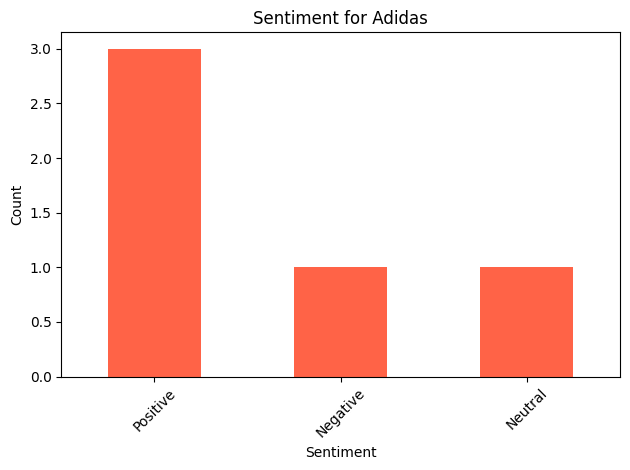

In [139]:
count = filtered_df['sentiment'].value_counts()
print(count)
count.plot(kind='bar',color='tomato')
plt.title(f'Sentiment for {'Adidas'}')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()